k_VV: O2_O2_regression_coefs.csv (50 переходов)


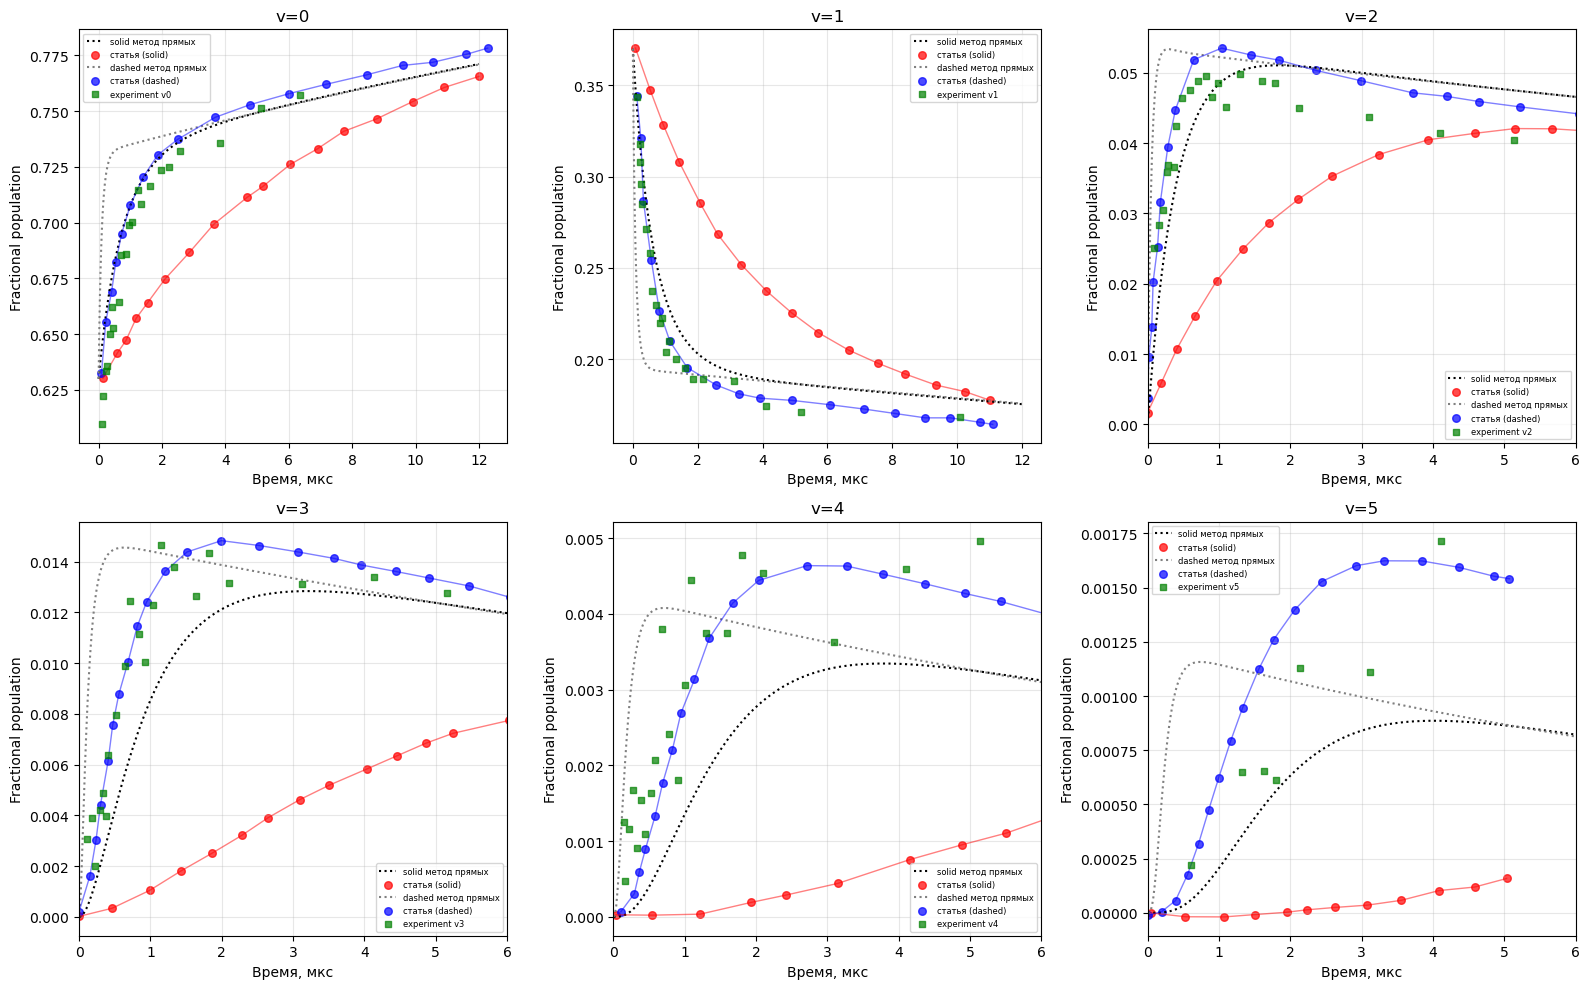


=== Результаты для метода 'method_of_lines' ===

--- solid: k_VV x 1 ---
t = 0.00 мкс:
  v=0: 0.630000
  v=1: 0.370000
  v=2: 0.000000
  v=3: 0.000000
  v=4: 0.000000
  v=5: 0.000000
t = 1.20 мкс:
  v=0: 0.714334
  v=1: 0.224076
  v=2: 0.049846
  v=3: 0.009716
  v=4: 0.001729
  v=5: 0.000300
t = 2.40 мкс:
  v=0: 0.734943
  v=1: 0.197982
  v=2: 0.050695
  v=3: 0.012583
  v=4: 0.003052
  v=5: 0.000744
t = 6.01 мкс:
  v=0: 0.752802
  v=1: 0.184717
  v=2: 0.046570
  v=3: 0.011968
  v=4: 0.003120
  v=5: 0.000822
t = 12.00 мкс:
  v=0: 0.771064
  v=1: 0.175457
  v=2: 0.040886
  v=3: 0.009697
  v=4: 0.002331
  v=5: 0.000566

--- dashed: k_VV x 8 ---
t = 0.00 мкс:
  v=0: 0.630000
  v=1: 0.370000
  v=2: 0.000000
  v=3: 0.000000
  v=4: 0.000000
  v=5: 0.000000
t = 1.20 мкс:
  v=0: 0.735766
  v=1: 0.192821
  v=2: 0.051985
  v=3: 0.014302
  v=4: 0.003996
  v=5: 0.001129
t = 2.40 мкс:
  v=0: 0.740188
  v=1: 0.190827
  v=2: 0.050549
  v=3: 0.013655
  v=4: 0.003744
  v=5: 0.001038
t = 6.01 мкс:
  v=0

In [1]:
from pathlib import Path
from io import StringIO
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

# ========== ВЫБОР МЕТОДА УЧЁТА ДИФФУЗИИ ==========
METHOD = "method_of_lines"   # "none", "analytic_factor", "method_of_lines"
# =================================================

BASE_DIR = Path('.').resolve()
PARTICLE_A, PARTICLE_B = "O2", "O2"
# REGRESSION_COEFFS_PATH = BASE_DIR / f"{PARTICLE_A}_{PARTICLE_B}_regression_coefs12312.csv"
# REGRESSION_COEFFS_PATH = BASE_DIR / f"{PARTICLE_A}_{PARTICLE_B}_regression_coefs.csv"
REGRESSION_COEFFS_PATH = BASE_DIR / "regression_coefficients" / f"{PARTICLE_A}_{PARTICLE_B}_regression_coefs.csv"
FIGURES_PATH = BASE_DIR / "figures" / f"{PARTICLE_A}_{PARTICLE_B}_modeling_1.png"

# ... (функции coeffs_dict_from_regression_csv, k_lookup, R_VV_fast, read_csv_with_comma_fix, load_experimental_data) остаются без изменений ...
# Они приведены ниже для полноты кода

def coeffs_dict_from_regression_csv(path: Path):
    df = pd.read_csv(path)
    a_cols = sorted(
        (c for c in df.columns if c.startswith("a_")),
        key=lambda s: int(s.split("_")[1]),
    )
    out = {}
    for _, row in df.iterrows():
        key = "_".join(str(int(row[c])) for c in ("i1", "f1", "i2", "f2"))
        coeffs = []
        for cname in a_cols:
            val = row[cname]
            if pd.isna(val):
                continue
            coeffs.append(float(val))
        out[key] = coeffs
    return out

if REGRESSION_COEFFS_PATH.exists():
    COEFFS = coeffs_dict_from_regression_csv(REGRESSION_COEFFS_PATH)
    print(f"k_VV: {REGRESSION_COEFFS_PATH.name} ({len(COEFFS)} переходов)")
else:
    with open(BASE_DIR / "coeffs_sparse2.json", "r") as f:
        COEFFS = json.load(f)
    print("k_VV: fallback coeffs_sparse2.json")

def k_lookup(coeffs_dict, i1, f1, i2, f2, T, rate_multiplier=1.0):
    key = f"{i1}_{f1}_{i2}_{f2}"
    coeffs = coeffs_dict.get(key)
    if coeffs is None:
        return 0.0
    x = T ** (-1/3)
    return rate_multiplier * np.exp(sum(c * x ** i for i, c in enumerate(coeffs)))

def R_VV_fast(v, N, v_max, T, coeffs=COEFFS, rate_multiplier=1.0):
    R = 0.0
    for v_ in range(v_max + 1):
        k1 = k2 = k3 = k4 = 0.0
        if v + 1 <= v_max and v_ + 1 <= v_max:
            k1 = k_lookup(coeffs, i1=v_, i2=v+1, f1=v_+1, f2=v, T=T, rate_multiplier=rate_multiplier)
        if v - 1 >= 0 and v_ - 1 >= 0:
            k2 = k_lookup(coeffs, i1=v_, f1=v_-1, i2=v-1, f2=v, T=T, rate_multiplier=rate_multiplier)
        if v - 1 >= 0 and v_ + 1 <= v_max:
            k3 = k_lookup(coeffs, i1=v_, f1=v_+1, i2=v, f2=v-1, T=T, rate_multiplier=rate_multiplier)
        if v + 1 <= v_max and v_ - 1 >= 0:
            k4 = k_lookup(coeffs, i1=v_, f1=v_-1, i2=v, f2=v+1, T=T, rate_multiplier=rate_multiplier)
        Nvp1 = N[v+1] if v+1 <= v_max else 0.0
        Nvm1 = N[v-1] if v-1 >= 0 else 0.0
        R += (k1 * Nvp1 + k2 * Nvm1 - (k3 + k4) * N[v]) * N[v_]
    return R # * 2.7

def read_csv_with_comma_fix(filename, sep=";"):
    with open(BASE_DIR / filename, "r", encoding="utf-8") as f:
        content = f.read()
    return pd.read_csv(StringIO(content.replace(",", ".")), sep=sep, header=None)

def load_experimental_data(v_max):
    exp_data = {"solid": [], "dashed": [], "dots": []}
    for v in range(v_max + 1):
        exp_data["solid"].append(read_csv_with_comma_fix(f"v{v}solid.csv"))
        exp_data["dashed"].append(read_csv_with_comma_fix(f"v{v}dashed.csv"))
        exp_data["dots"].append(read_csv_with_comma_fix(f"experimentv{v}.csv"))
    return exp_data

# ========== ФИЗИЧЕСКИЕ ПАРАМЕТРЫ ==========
t_span = (0, 12e-6)
t_eval = np.linspace(0, 12e-6, 600)
T = 300
V_MAX = 5
N_TOTAL = 5.07e18               # см^-3

initial_fractions = np.zeros(V_MAX + 1)
initial_fractions[0] = 0.63
initial_fractions[1] = 0.37

# mult = 3 gives better results
mult = 1
rate_multipliers = {
    "solid": mult,
    "dashed": 8 * mult
}

# Параметры гауссовых пучков (одинаковые для простоты)
sigma_pump_cm = 80e-4    # 46 мкм
sigma_probe_cm = 40e-4

# Коэффициент самодиффузии N2 при 760 Торр, 300 K (см^2/с)
D_N2 = 0.2                # типичное значение для N2
P_torr = 760
D = D_N2 * (760.0 / P_torr)

# ========== ПОСТРОЕНИЕ НАЧАЛЬНОГО РАСПРЕДЕЛЕНИЯ ДЛЯ МЕТОДА ПРЯМЫХ ==========
# def build_initial_state_method_of_lines(N_r, R_max):
#     """Создаёт начальное состояние для метода прямых: массив (V_MAX+1, N_r)."""
#     dr = R_max / (N_r - 1)
#     r = np.linspace(0, R_max, N_r)
#     # Гауссов профиль возбуждения: n_1(r) ~ exp(-2 r^2 / sigma_pump^2)
#     profile = np.exp(-2.0 * r**2 / sigma_pump_cm**2)
#     # Амплитуда такой, чтобы после усреднения с пробным пучком (sigma_probe)
#     # получалась f1 = initial_fractions[1]
#     # Веса пробного пучка: w_probe = r * exp(-2 r^2 / sigma_probe^2) (потом нормировка)
#     w_probe = r * np.exp(-2.0 * r**2 / sigma_probe_cm**2)
#     # Нормировочный интеграл для полной концентрации
#     integral_total = np.trapezoid(N_TOTAL * w_probe, r)
#     integral_profile = np.trapezoid(profile * w_probe, r)
#     # Усреднённая доля = A * integral_profile / integral_total, где A - амплитуда profile
#     A = (initial_fractions[1] * integral_total) / integral_profile
#     n1_init = A * profile
#     n0_init = N_TOTAL - n1_init
#     # Собираем матрицу (V_MAX+1, N_r)
#     state = np.zeros((V_MAX + 1, N_r))
#     state[0, :] = n0_init
#     state[1, :] = n1_init
#     return state, r, dr

def build_initial_state_method_of_lines(N_r, R_max):
    """Создаёт начальное состояние для метода прямых: массив (V_MAX+1, N_r)."""
    dr = R_max / (N_r - 1)
    r = np.linspace(0, R_max, N_r)
    # Гауссов профиль возбуждения: n_1(r) ~ exp(-2 r^2 / sigma_pump^2)
    profile = np.exp(-2.0 * r**2 / sigma_pump_cm**2)
    # Амплитуда такой, чтобы после усреднения с пробным пучком (sigma_probe)
    # получалась f1 = initial_fractions[1]
    # Веса пробного пучка: w_probe = r * exp(-2 r^2 / sigma_probe^2) (потом нормировка)
    w_probe = r * np.exp(-2.0 * r**2 / sigma_probe_cm**2)
    # Нормировочный интеграл для полной концентрации
    integral_total = np.trapz(N_TOTAL * w_probe, r)
    integral_profile = np.trapz(profile * w_probe, r)
    # Усреднённая доля = A * integral_profile / integral_total, где A - амплитуда profile
    A = (initial_fractions[1] * integral_total) / integral_profile
    n1_init = A * profile
    n0_init = N_TOTAL - n1_init
    # Собираем матрицу (V_MAX+1, N_r)
    state = np.zeros((V_MAX + 1, N_r))
    state[0, :] = n0_init
    state[1, :] = n1_init
    return state, r, dr

def laplacian_cyl(f, r, dr):
    """Дискретный оператор Лапласа в цилиндр. координатах для равномерной сетки.
       f: 1D массив значений в узлах r. Возвращает массив той же формы.
       Граничные условия: симметрия при r=0 (df/dr=0), f=0 на внешней границе.
    """
    N = len(r)
    lap = np.zeros_like(f)
    # Внутренние узлы (индексы 1..N-2)
    for i in range(1, N-1):
        ri = r[i]
        # Половинные индексы
        r_plus  = ri + 0.5*dr
        r_minus = ri - 0.5*dr
        lap[i] = (1.0/ri) * ( (r_plus * (f[i+1] - f[i]) - r_minus * (f[i] - f[i-1])) / dr**2 )
    # Узел на оси (i=0)
    lap[0] = 4.0 * (f[1] - f[0]) / dr**2
    # Внешняя граница (i=N-1) – фиксировано f=0, поэтому лапласиан можно не считать,
    # но для порядка оставим как линейную экстраполяцию:
    lap[-1] = 0.0   # т.к. условие f=0, всё равно решение не войдёт в эту область
    return lap

# ========== ПРАВАЯ ЧАСТЬ ДЛЯ МЕТОДА ПРЯМЫХ ==========
def rhs_method_of_lines(t, state_flat, v_max, N_r, r, dr, T, D, rate_multiplier):
    """state_flat упакован как: сначала все r для v=0, потом v=1, и т.д."""
    state = state_flat.reshape((v_max+1, N_r))   # (v_max+1) x N_r
    dstate = np.zeros_like(state)

    # Лапласианы для v>0
    laplacians = np.zeros((v_max+1, N_r))
    for v in range(1, v_max+1):
        laplacians[v, :] = laplacian_cyl(state[v, :], r, dr)
    # Сумма лапласианов возбуждённых уровней для компенсации в v=0
    sum_lapl_positive = np.sum(laplacians[1:, :], axis=0)   # по всем v>0

    # Для каждого радиального узла вычисляем VV-кинетику
    for i in range(N_r):
        local_N = state[:, i]   # вектор концентраций по v в узле i
        # V-V член для каждого уровня
        for v in range(v_max+1):
            dstate[v, i] = R_VV_fast(v, local_N, v_max, T, rate_multiplier=rate_multiplier)

    # Добавляем диффузию: для v>0 прибавляем D*laplacian, для v=0 вычитаем D*sum_lapl_positive
    for v in range(1, v_max+1):
        dstate[v, :] += D * laplacians[v, :]
    dstate[0, :] -= D * sum_lapl_positive

    return dstate.flatten()

# def spatial_average(state, r, dr, sigma_probe):
#     """Усреднение концентраций по гауссову пробному объёму."""
#     # Весовая функция: r * exp(-2 r^2 / sigma_probe^2)
#     w = r * np.exp(-2.0 * r**2 / sigma_probe**2)
#     norm = np.trapezoid(w, r)
#     w_norm = w / norm
#     avg = np.trapezoid(state * w_norm[np.newaxis, :], r, axis=1)
#     return avg   # массив длиной v_max+1

def spatial_average(state, r, dr, sigma_probe):
    """Усреднение концентраций по гауссову пробному объёму."""
    # Весовая функция: r * exp(-2 r^2 / sigma_probe^2)
    w = r * np.exp(-2.0 * r**2 / sigma_probe**2)
    norm = np.trapz(w, r)
    w_norm = w / norm
    avg = np.trapz(state * w_norm[np.newaxis, :], r, axis=1)
    return avg   # массив длиной v_max+1

# ========== УНИВЕРСАЛЬНАЯ ФУНКЦИЯ РЕШЕНИЯ ==========
def solve_for_rate_multiplier(initial_fractions, rate_multiplier, method="none"):
    """
    method : "none" – без диффузии
             "analytic_factor" – аналитический фактор
             "method_of_lines" – метод прямых
    """
    if method in ("none", "analytic_factor"):
        # Однородная начальная концентрация (как раньше)
        N_init = initial_fractions * N_TOTAL
        sol = solve_ivp(
            lambda t, N: rhs_time(t, N, V_MAX, T, rate_multiplier),
            t_span,
            N_init,
            t_eval=t_eval,
            method="Radau",
        )
        if not sol.success:
            raise RuntimeError(f"solve_ivp failed: {sol.message}")
        if method == "analytic_factor":
            # Аналитический фактор
            R = 1.0 / np.sqrt(1.0 + 4.0 * D * sol.t / (sigma_pump_cm**2 + sigma_probe_cm**2))
            N_corrected = sol.y * R[np.newaxis, :]
            fractional = N_corrected / N_TOTAL
        else:
            fractional = sol.y / np.sum(sol.y, axis=0)
        return sol, fractional

    elif method == "method_of_lines":
        # Параметры сетки
        R_max = 200e-4   # 200 мкм
        N_r = 80
        dr = R_max / (N_r - 1)
        r = np.linspace(0, R_max, N_r)

        # Начальное пространственное распределение
        state_init, r, dr = build_initial_state_method_of_lines(N_r, R_max)
        state_flat = state_init.flatten()

        sol = solve_ivp(
            lambda t, y: rhs_method_of_lines(t, y, V_MAX, N_r, r, dr, T, D, rate_multiplier),
            t_span,
            state_flat,
            t_eval=t_eval,
            method="Radau",
            rtol=1e-9,
            atol=1e6,
        )
        if not sol.success:
            raise RuntimeError(f"solve_ivp failed: {sol.message}")

        # Усреднение по пробному объёму для каждого момента времени
        n_t_avg = np.zeros((V_MAX+1, len(sol.t)))
        for idx, t in enumerate(sol.t):
            state_t = sol.y[:, idx].reshape((V_MAX+1, N_r))
            n_t_avg[:, idx] = spatial_average(state_t, r, dr, sigma_probe_cm)
        fractional = n_t_avg / N_TOTAL   # доли от полной концентрации
        return sol, fractional

    else:
        raise ValueError("Неизвестный метод")

# Старая rhs_time (для методов без пространственной сетки)
def rhs_time(t, N, v_max, T, rate_multiplier):
    dNdt = np.zeros_like(N)
    for v in range(v_max + 1):
        dNdt[v] = R_VV_fast(v, N, v_max, T, rate_multiplier=rate_multiplier)
    return dNdt

# Загрузка экспериментальных данных
exp_data = load_experimental_data(V_MAX)

# ========== РАСЧЁТ ДЛЯ ВСЕХ МЕТОДОВ ==========
simulations = {}
for style, mult_val in rate_multipliers.items():
    simulations[style] = {}
    for method in ["none", "analytic_factor", "method_of_lines"]:
        sol, frac = solve_for_rate_multiplier(initial_fractions, mult_val, method=method)
        simulations[style][method] = {"sol": sol, "fractional": frac}

# ========== ГРАФИКИ (сравнение методов для одного стиля) ==========
plot_styles = {
    "solid": {"color": "black", "exp_color": "red"},
    "dashed": {"color": "gray", "exp_color": "blue"},
}
method_labels = {
    "none": "без дифф.",
    "analytic_factor": "аналит. фактор",
    "method_of_lines": "метод прямых",
}
method_linestyles = {"none": "-", "analytic_factor": "--", "method_of_lines": ":"}

plt.style.use('default')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# for v in range(min(6, V_MAX + 1)):
#     ax = axes[v]
#     for style, sty_params in plot_styles.items():
#         sim = simulations[style]
#         for method in ["none", "analytic_factor", "method_of_lines"]:
#             if method == METHOD or METHOD == "all":
#                 t = sim[method]["sol"].t * 1e6
#                 frac = sim[method]["fractional"][v, :]
#                 ax.plot(t, frac,
#                         color=sty_params["color"],
#                         linestyle=method_linestyles[method],
#                         linewidth=1.5,
#                         label=f"{style} {method_labels[method]}")
#         # Экспериментальные точки
#         data = exp_data[style][v]
#         if data is not None and len(data) > 0:
#             t_exp = data.iloc[:, 0].values.astype(float)
#             pop_exp = data.iloc[:, 1].values.astype(float)
#             ax.scatter(t_exp, pop_exp, marker="o", s=30,
#                        color=sty_params["exp_color"], alpha=0.7,
#                        label=f"статья ({style})")
#             ax.plot(t_exp, pop_exp, linestyle="-", linewidth=1,
#                     color=sty_params["exp_color"], alpha=0.5)
#
#     ax.set_xlabel("Время, мкс")
#     ax.set_ylabel("Fractional population")
#     ax.set_title(f"v={v}")
#     ax.grid(True, alpha=0.3)
#     ax.legend(fontsize=6)

for v in range(min(6, V_MAX + 1)):
    ax = axes[v]
    for style, sty_params in plot_styles.items():
        sim = simulations[style]
        for method in ["none", "analytic_factor", "method_of_lines"]:
            if method == METHOD or METHOD == "all":
                t = sim[method]["sol"].t * 1e6
                frac = sim[method]["fractional"][v, :]
                ax.plot(t, frac,
                        color=sty_params["color"],
                        linestyle=method_linestyles[method],
                        linewidth=1.5,
                        label=f"{style} {method_labels[method]}")
        # Экспериментальные точки (solid и dashed) - оставляем как было
        data = exp_data[style][v]
        if data is not None and len(data) > 0:
            t_exp = data.iloc[:, 0].values.astype(float)
            pop_exp = data.iloc[:, 1].values.astype(float)
            ax.scatter(t_exp, pop_exp, marker="o", s=30,
                       color=sty_params["exp_color"], alpha=0.7,
                       label=f"статья ({style})")
            ax.plot(t_exp, pop_exp, linestyle="-", linewidth=1,
                    color=sty_params["exp_color"], alpha=0.5)

    # ДОБАВИТЬ ЭТОТ БЛОК - только для dots (experimentvX.csv)
    dots_data = exp_data["dots"][v]
    if dots_data is not None and len(dots_data) > 0:
        t_dots = dots_data.iloc[:, 0].values.astype(float)
        pop_dots = dots_data.iloc[:, 1].values.astype(float)
        ax.scatter(t_dots, pop_dots, marker="s", s=25,
                  color="green", alpha=0.7,
                  label=f"experiment v{v}", zorder=3)

    ax.set_xlabel("Время, мкс")
    ax.set_ylabel("Fractional population")
    ax.set_title(f"v={v}")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6)

for v in range(2, 6):
    axes[v].set_xlim(0, 6)

plt.tight_layout()
plt.savefig(FIGURES_PATH, dpi=300, bbox_inches="tight", facecolor='white')
plt.show()


# ========== ВЫВОД ЧИСЛЕННЫХ ЗНАЧЕНИЙ ==========
print(f"\n=== Результаты для метода '{METHOD}' ===")
for style, result in simulations.items():
    print(f"\n--- {style}: k_VV x {rate_multipliers[style]:g} ---")
    sol = result[METHOD]["sol"]
    frac = result[METHOD]["fractional"]
    time_indices = [0, len(sol.t)//10, len(sol.t)//5, len(sol.t)//2, -1]
    for ti in time_indices:
        print(f"t = {sol.t[ti]*1e6:.2f} мкс:")
        for v in range(min(6, V_MAX+1)):
            print(f"  v={v}: {frac[v, ti]:.6f}")